## Identification attacks

 ### Dataset
 
 - **Dataset:** Consists of an individual's data:
 
 - **Attributes:** name, SSD, phone number, e-mail address, Zip, address, date of birth, age, education, etc.
 
 - **Analysing data:** 
   - Publish an anonymized version of the dataset.
   - Publish the result of queries.
 
  - **Goals:** 
    - The result should be accurate.
    - Don't violate privacy.

### Attributes

 - Identifiers: provide unambiguous identification—E.g, name, e-mail address, phone number, SSN, address, etc.
 - Quasi-identifiers: individually, do not uniquely identify a person but can, when combined with other quasi-identifiers or external information, lead to the re-identification of an individual, etc., sex, dob, zip code, age, etc.
 - Confidential/sensitive: data that must be protected. They can also be quasi-identifiers.

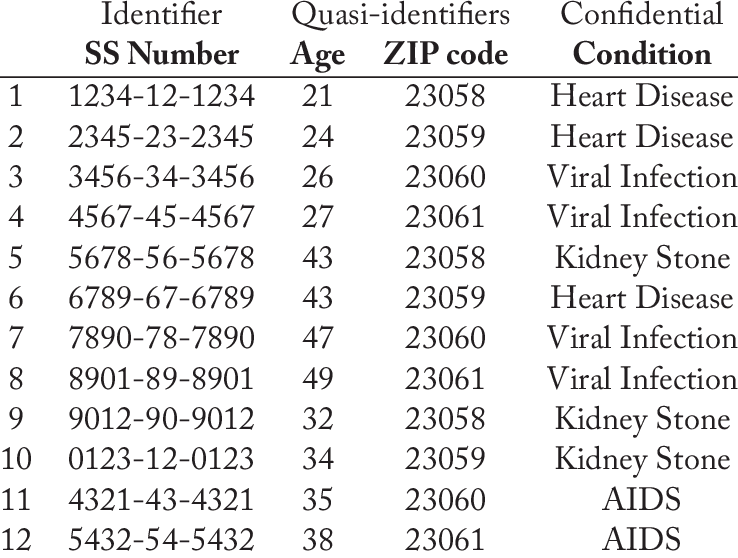

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
adult = pd.read_csv("data.csv")
adult.head(20)

,Name,First Name,Last Name,Sex,SSN,DOB,Birthday,Age,Zip,Education,Marital Status,Occupation,Salary
0,Jason Ortiz,Jason,Ortiz,Male,239-62-5065,12/24/65,12/24,58,55813,Bachelors degree,Widowed,Engineer/ production,Under 25k
1,Anna Brown,Anna,Brown,Female,860-48-3325,03/21/99,03/21,25,25593,Bachelors degree,Never married,Systems developer,100k to 200k
2,Kevin Anderson,Kevin,Anderson,Male,176-24-2913,05/11/67,05/11,57,29066,No degree,Never married,Equities trader,50k to 100k
3,Patricia Clarke,Patricia,Clarke,Female,384-30-3488,12/23/76,12/23,47,81645,High school/GED,Divorce,Restaurant manager,50k to 100k
4,Robert Watson,Robert,Watson,Male,066-16-3817,04/08/01,04/08,23,27301,No degree,Married,Facilities manager,25k to 50k
5,Joseph Carrillo,Joseph,Carrillo,Male,426-75-3893,12/23/88,12/23,35,60983,Masters degree,Never married,Designer/ multimedia,100k to 200k
6,Molly Rodriguez,Molly,Rodriguez,Female,610-28-1657,07/24/88,07/24,36,83909,Bachelors degree,Married,Theatre director,Under 25k
7,Kenneth Smith,Kenneth,Smith,Male,521-01-8305,04/14/02,04/14,22,90525,High school/GED,Never married,Oceanographer,50k to 100k
8,Andrea Hale,Andrea,Hale,Female,586-74-2173,10/27/97,10/27,26,16072,Associate degree,Never married,Solicitor,50k to 100k
9,Tamara Reyes,Tamara,Reyes,Female,034-40-4605,11/04/93,11/04,30,17275,High school/GED,Married,Adult nurse,25k to 50k


### How to defend against re-identification? 

  - Remove every identifier, etc., name, first name, last name, SSN.
  - Is it enough?

In [3]:
adult_data = adult.copy().drop(columns=['Name', 'First Name', 'Last Name', 'SSN'])
adult_pii = adult[['Name', 'SSN', 'DOB', 'Zip']]
adult_data.head(5) 
     

,Sex,DOB,Birthday,Age,Zip,Education,Marital Status,Occupation,Salary
0,Male,12/24/65,12/24,58,55813,Bachelors degree,Widowed,Engineer/ production,Under 25k
1,Female,03/21/99,03/21,25,25593,Bachelors degree,Never married,Systems developer,100k to 200k
2,Male,05/11/67,05/11,57,29066,No degree,Never married,Equities trader,50k to 100k
3,Female,12/23/76,12/23,47,81645,High school/GED,Divorce,Restaurant manager,50k to 100k
4,Male,04/08/01,04/08,23,27301,No degree,Married,Facilities manager,25k to 50k


### Linkage attack

Identify a person from a dataset using auxiliary information.
 - Same data but at a different time.
 - Link different datasets (Netflix and IMDB).
 - Auxiliary information.

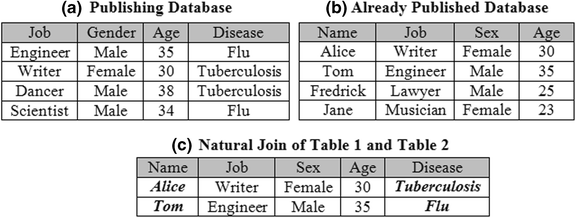

Apply a linkage attack for large datasets:
   - We know Anna Brown.
   - We want to learn about her income.
   - We know her date of birth.
   - We know her zipcode.

 - We look at the overlapping columns between the dataset we're trying to attack and the auxiliary data we know.
 - We look for rows with dates of birth and zip codes that match Anna's date of birth and zip code.
 - If there is only one such raw, then we identified Anna.

In [4]:
annas_row = adult_pii[adult_pii['Name'] == 'Anna Brown']
pd.merge(annas_row, adult_data, left_on=['DOB', 'Zip'], right_on=['DOB','Zip'])

,Name,SSN,DOB,Zip,Sex,Birthday,Age,Education,Marital Status,Occupation,Salary
0,Anna Brown,860-48-3325,03/21/99,25593,Female,03/21,25,Bachelors degree,Never married,Systems developer,100k to 200k


 - There is only one row that matches. We learned that Anna's income is between 100k and 200k.

### How hard is it to re-identify Anna

 - What if we know less?
 - Can we re-identify Anna from only her Zip code?
 - Can we re-identify Anna from only her date of birth?

In [5]:
pd.merge(annas_row, adult_data, left_on=['Zip'], right_on=['Zip'])

,Name,SSN,DOB_x,Zip,Sex,DOB_y,Birthday,Age,Education,Marital Status,Occupation,Salary
0,Anna Brown,860-48-3325,03/21/99,25593,Female,03/21/99,03/21,25,Bachelors degree,Never married,Systems developer,100k to 200k


The zip code alone is enough to identify Anna.

In [6]:
pd.merge(annas_row, adult_data, left_on=['DOB'], right_on=['DOB'])

,Name,SSN,DOB,Zip_x,Sex,Birthday,Age,Zip_y,Education,Marital Status,Occupation,Salary
0,Anna Brown,860-48-3325,03/21/99,25593,Female,03/21,25,25593,Bachelors degree,Never married,Systems developer,100k to 200k
1,Anna Brown,860-48-3325,03/21/99,25593,Male,03/21,25,40489,Masters degree,Married,Network engineer,Under 25k


 - The date of birth restricts the number of possibilities to only two people.
 - We know that Annas salary is *100k to 200k* or *Under 25k*.
 - With some additional information (*Sex* or *Marital status* or *Education*) we can identify Annas salary.

### Is Anna special?

 - How hard is it to re-identify others? Is Anna special?
 - Is it common for a date of birth to occur more than once?
 - The histogram shows that the vast majority of dates of birth occur 1, 2, or 3 times in the dataset.
 - *No date of birth* occurs more than 6.

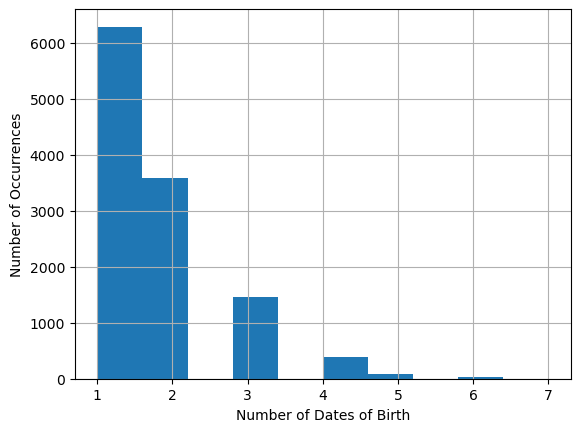

In [7]:
adult_pii['DOB'].value_counts().hist()
plt.xlabel('Number of Dates of Birth')
plt.ylabel('Number of Occurrences');

- What about the zip codes?

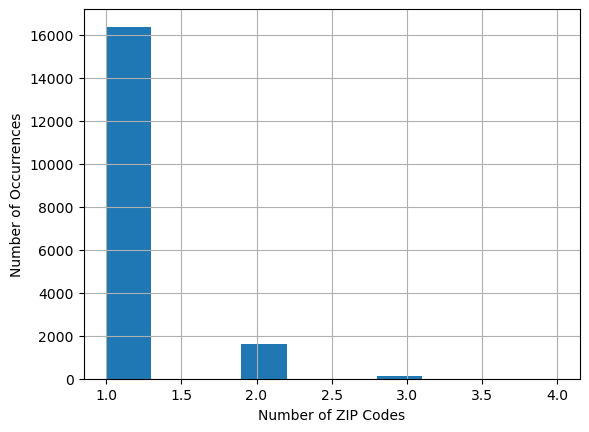

In [8]:
 adult_pii['Zip'].value_counts().hist()
plt.xlabel('Number of ZIP Codes')
plt.ylabel('Number of Occurrences');

- Majority of the zip codes appear only once.

 ### How many people can we re-identify?
    
 - What if we use just the date of birth?
 - We want to know how many *possible identities* are returned for each *name* in the dateset:

,Name,SSN,DOB,Zip_x,Sex,Birthday,Age,Zip_y,Education,Marital Status,Occupation,Salary
0,Jason Ortiz,239-62-5065,12/24/65,55813,Male,12/24,58,55813,Bachelors degree,Widowed,Engineer/ production,Under 25k
1,Jason Ortiz,239-62-5065,12/24/65,55813,Female,12/24,58,10529,High school/GED,Never married,Community education officer,Over 200k
2,Anna Brown,860-48-3325,03/21/99,25593,Female,03/21,25,25593,Bachelors degree,Never married,Systems developer,100k to 200k
3,Anna Brown,860-48-3325,03/21/99,25593,Male,03/21,25,40489,Masters degree,Married,Network engineer,Under 25k
4,Kevin Anderson,176-24-2913,05/11/67,29066,Male,05/11,57,29066,No degree,Never married,Equities trader,50k to 100k
5,Kevin Anderson,176-24-2913,05/11/67,29066,Male,05/11,57,52822,Some college,Divorce,Armed forces logistics/support/administrative ...,100k to 200k
6,Kevin Anderson,176-24-2913,05/11/67,29066,Male,05/11,57,49364,High school/GED,Married,Operational researcher,25k to 50k
7,Patricia Clarke,384-30-3488,12/23/76,81645,Female,12/23,47,81645,High school/GED,Divorce,Restaurant manager,50k to 100k
8,Patricia Clarke,384-30-3488,12/23/76,81645,Female,12/23,47,13966,Some college,Never married,Engineer/ land,25k to 50k
9,Robert Watson,066-16-3817,04/08/01,27301,Male,04/08,23,27301,No degree,Married,Facilities manager,25k to 50k


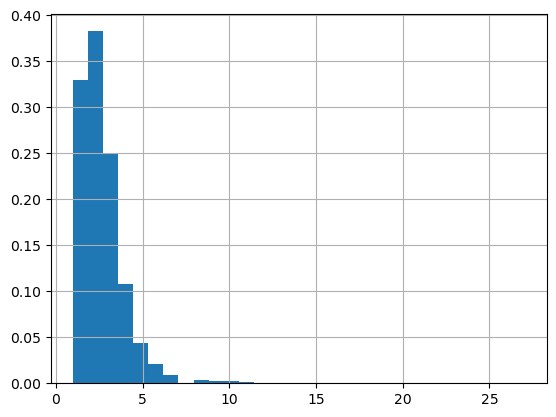

In [9]:
attack = pd.merge(adult_pii, adult_data, left_on=['DOB'], right_on=['DOB'])
attack['Name'].value_counts().hist(bins = 30, density = True);
attack.head(20)

 - The results show that we can uniquely identify more than 32 percent of people based on only the date of birth.
 - An additional 37-38 percent are narrowed down to two possibilities.
 - Only a few can have more than 7 possibilities.
 - Can we do better if we use ZIP too?

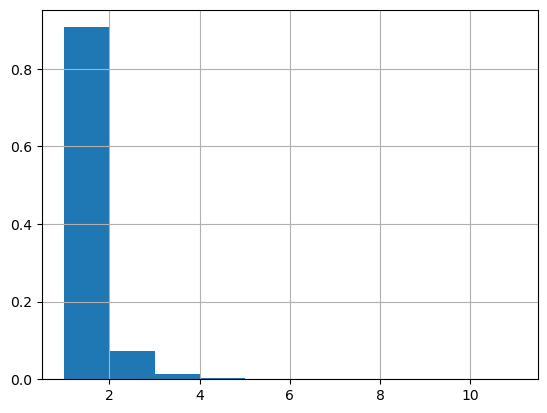

In [10]:
attack = pd.merge(adult_pii, adult_data, left_on=['DOB', 'Zip'], right_on=['DOB', 'Zip'])
attack['Name'].value_counts().hist(density = True);

 - We could uniquely identify almost 90 percent.
 - We could narrow down to two possibilities for almost 98 percent.
 - According to Latanya Sweeney's work, 87% of people in the US can be uniquely re-identified by the combination of date of birth, gender, and Zip code.
 - We fail to identify some because specific names appear in the dataset multiple times.

In [11]:
attack['Name'].value_counts().head(500)

Name
James Johnson     11
Michael Smith     11
David Williams    10
Michael Jones     10
Robert Johnson     9
                  ..
Denise Roberts     2
Connor Miller      2
Jeffery White      2
James Scott        2
James Fowler       2
Name: count, Length: 500, dtype: int64

In [12]:
adult['Name'].value_counts().head(100)

Name
James Johnson      11
Michael Smith      11
David Williams     10
Michael Jones      10
Robert Johnson      9
                   ..
Ashley Johnson      4
Angela Williams     4
Tracy Brown         4
Jennifer Jones      4
Brandon Smith       4
Name: count, Length: 100, dtype: int64

## $k$-Anonymity

The dataset is $k$-Anonymized for a particular $k$ if each individual in the dataset is a member of a group of size at least $k$, such that each member of the group shares the same quasi-identifiers with all other members of the group (quasi-identifiers - non-identifying attributes).

 - Informally: individuals in each group *blend into* their group (*blend into the crowd*).

 - It is possible to narrow down an individual to membership in a particular group, but not to determine which group member is the target.


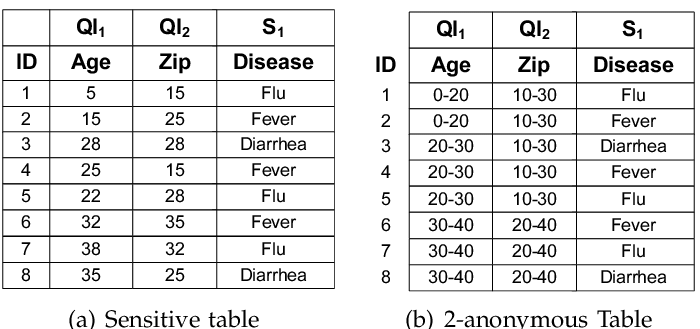

In [13]:
raw_data = {
    'first_name': ['Jason', 'Molly', 'Tina', 'Jake', 'Amy'], 
    'last_name': ['Miller', 'Jacobson', 'Ali', 'Milner', 'Cooze'], 
    'gradeMath': [4, 5, 5, 5, 4, 3, 5, 3],
    'gradeBiology': [5, 4, 4, 4, 5, 4, 4, 4]}
#df = pd.DataFrame(raw_data, columns = ['first_name', 'last_name', 'age', 'preTestScore', 'postTestScore'])
df_grade = pd.DataFrame(raw_data, columns = ['gradeMath', 'gradeBiology'])
df_grade

,gradeMath,gradeBiology
0,4,5
1,5,4
2,5,4
3,5,4
4,4,5
5,3,4
6,5,4
7,3,4


### Checking for $k$-Anonymity

 - Any dataset trivially satisfies $k$-Anonimity for $k=1$.
 - Let's start with a small dataset, so it is easy to check for $ k$-Anonymity. 

In [14]:
raw_data = {
    'first_name': ['Jason', 'Molly', 'Tina', 'Jake', 'Amy'], 
    'last_name': ['Miller', 'Jacobson', 'Ali', 'Milner', 'Cooze'], 
    'age': [42, 52, 36, 24, 73], 
    'preTestScore': [4, 24, 31, 2, 3],
    'postTestScore': [25, 94, 57, 62, 70]}
#df = pd.DataFrame(raw_data, columns = ['first_name', 'last_name', 'age', 'preTestScore', 'postTestScore'])
df_score = pd.DataFrame(raw_data, columns = ['age', 'preTestScore', 'postTestScore'])
df_score

,age,preTestScore,postTestScore
0,42,4,25
1,52,24,94
2,36,31,57
3,24,2,62
4,73,3,70


In [15]:
def isKAnonymized(df, k):
    for index, row in df.iterrows():
        query = ' & '.join([f'{col} == {row[col]}' for col in df.columns])
        rows = df.query(query)
        if rows.shape[0] < k:
            return False
    return True

In [16]:
isKAnonymized(df_score, 1)

True

In [17]:
isKAnonymized(df_score, 2)

False

### Generalizing Data to Satisfy $k$-Anonymity

 How to modify a dataset to satisfy $k$-Anonymity?
  - Modify values to be less specific, e.g., age: round up to 10, Zip: replace the rightmost digits by zeros, etc.
  - Remove quasi-identifiers
  
 The following code replaces the last *depth* digits of the value with zeros:

In [18]:
def generalize(df, depths):
    return df.apply(lambda x: x.apply(lambda y: int(int(y/(10**depths[x.name]))*(10**depths[x.name]))))

In [19]:
depths = {
    'age': 1,
    'preTestScore': 1,
    'postTestScore': 1
}
df_score2 = generalize(df_score, depths)
df_score2

,age,preTestScore,postTestScore
0,40,0,20
1,50,20,90
2,30,30,50
3,20,0,60
4,70,0,70


The dataset still does not satisfy $k$-Anonymity.

In [20]:
isKAnonymized(df_score2, 2)

False

In [22]:
depths = {
    'age': 2,
    'preTestScore': 2,
    'postTestScore': 2
}
df_score3 = generalize(df_score, depths)
df_score3

,age,preTestScore,postTestScore
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [23]:
isKAnonymized(df_score3, 2)

True

If we generalize further, it will eliminate all data. This example illustrates one of the key challenges of achieving $k$-Anonymity:

>*Achieving $k$-Anonymity for meaningful values often requires removing quite a lot of information from the data.*

In [25]:
df_agezip = adult_data[['Age', 'Zip']]
df_agezip.columns = ['age', 'zip']
isKAnonymized(df_agezip.head(100), 1)

True

In [26]:
df_agezip.head(10)

,age,zip
0,58,55813
1,25,25593
2,57,29066
3,47,81645
4,23,27301
5,35,60983
6,36,83909
7,22,90525
8,26,16072
9,30,17275


In [28]:
depths = {
    'age': 1,
    'zip': 1
}
df_agezip2 = generalize(df_agezip.head(1000), depths)
isKAnonymized(df_agezip2, 2)

False

In [29]:
df_agezip2.head()

,age,zip
0,50,55810
1,20,25590
2,50,29060
3,40,81640
4,20,27300


In [30]:
depths = {
    'age': 1,
    'zip': 4
}
df_agezip3 = generalize(df_agezip.head(1000), depths)
isKAnonymized(df_agezip3, 2)

False

In [31]:
df_agezip3.head()

,age,zip
0,50,50000
1,20,20000
2,50,20000
3,40,80000
4,20,20000


*The dataset is not $k$-anonym even though we replaced 4 of the 5 digits of the *zip*s. What is the problem?*

### Outliers

The reason is that the dataset contains outliers:
> individuals who are very different from the rest of the population

These individuals do not fit easily into any group, even after generalization. E.g., 
 - people from a sparsely populated area.
 - elderly people

### Optimality of k-anonymity

 - Achieving the optimal generalization for k-anonymity is very challenging in cases like this. 
 - Generalizing each row more would be overkill for the well-represented individuals with ages in the 20-40 range, and would hurt utility. 
 - More generalization is needed for individuals at the upper and lower ends of the age range. 
 - This kind of challenge occurs regularly in practice and is difficult to solve automatically. Optimal generalization for -Anonymity is NP-hard.

>**Outliers make achieving $k$-anonymity very challenging, even for large datasets. The optimal generalization for $k$-anonymity is NP-hard.**


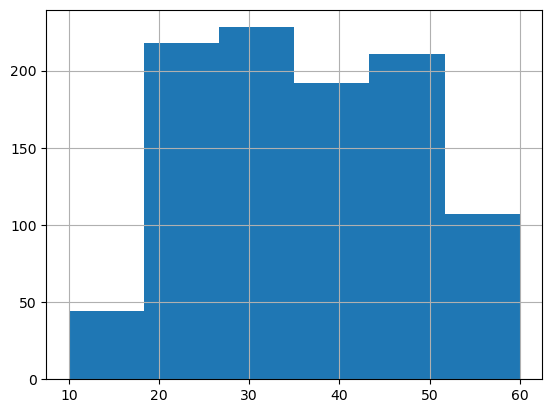

In [38]:
df_agezip2['age'].hist(bins = 6);

The number of individuals aged 10-20 and 60-70 is much lower than that of the other age groups. Let's try again after removing these people.

In [39]:
# clipping away outliers
depths = {
    'age': 1,
    'zip': 4
}
dfp = df_agezip.clip(upper=np.array([60, 100000]), axis='columns')
dfp = dfp.clip(lower=np.array([20, 1]), axis='columns')
df2 = generalize(dfp.head(1000), depths)
isKAnonymized(df2, 7)

True

In [40]:
df2.head(10)

,age,zip
0,50,50000
1,20,20000
2,50,20000
3,40,80000
4,20,20000
5,30,60000
6,30,80000
7,20,90000
8,20,10000
9,30,10000


The generalized, clipped dataset satisfies $ k$-anonymity for $k = 7$.

## Homogeneity Attack

 - Every individual is in a group of $k$, and it is indistinguishable from the other $k-1$.
 - Problem: If the sensitive attribute is the same for the group.
 - It is enough to identify the group.

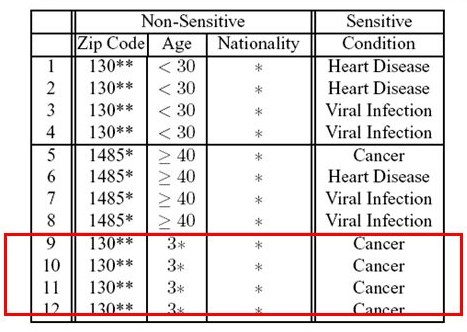

## Background Knowledge Attack

- Some background information helps identify the person's group.
- As the groups are more general, it is easier to identify the group with less information.
- For example, Machanavajjhala, Kifer, Gehrke, and Venkitasubramaniam (2007) showed that knowing that heart attacks occur at a reduced rate in Japanese patients could be used to narrow the range of values for a sensitive attribute of a patient's disease.